In [87]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import importlib
import EDA as eda 
import Feature_eng as feature_eng
importlib.reload(eda)
importlib.reload(feature_eng)



<module 'Feature_eng' from 'c:\\Users\\kaspe\\OneDrive\\Documents\\USYD-Kasper\\Year 3\\QBUS3820\\Assignment\\Code\\QBUS3820-Group-Assignment\\Feature_eng.py'>

In [2]:
import warnings
warnings.filterwarnings('ignore') 

# Plot settings
sns.set_context('notebook') # optimises figures for notebook display
sns.set_style('ticks') # set default plot style
colours = ['#4E79A7','#F28E2C','#E15759','#76B7B2','#59A14F', 
          '#EDC949','#AF7AA1','#FF9DA7','#9C755F','#BAB0AB']
sns.set_palette(colours) # set custom color scheme


%matplotlib inline
plt.rcParams['figure.figsize'] = (9, 6)
plt.rcParams['figure.dpi'] = 80
%config InlineBackend.figure_format = 'retina'

In [3]:
transactions, demographics, products, campaigns, campaign_descriptions, promotions = eda.retrieve_data()

### Define Churn variable

In [4]:
churn, churn_train, churn_valid, churn_test = feature_eng.churn(transactions, threshold_days=21)
print(churn.head())
print(churn.value_counts())
print(80*'=')
print(churn_train.value_counts())
print(churn_valid.value_counts())
print(churn_test.value_counts())

household_id
1    0
2    1
3    0
4    1
5    1
Name: churn, dtype: int64
churn
0    1897
1     572
Name: count, dtype: int64
churn
0    1332
1     396
Name: count, dtype: int64
churn
0    289
1     81
Name: count, dtype: int64
churn
0    276
1     95
Name: count, dtype: int64


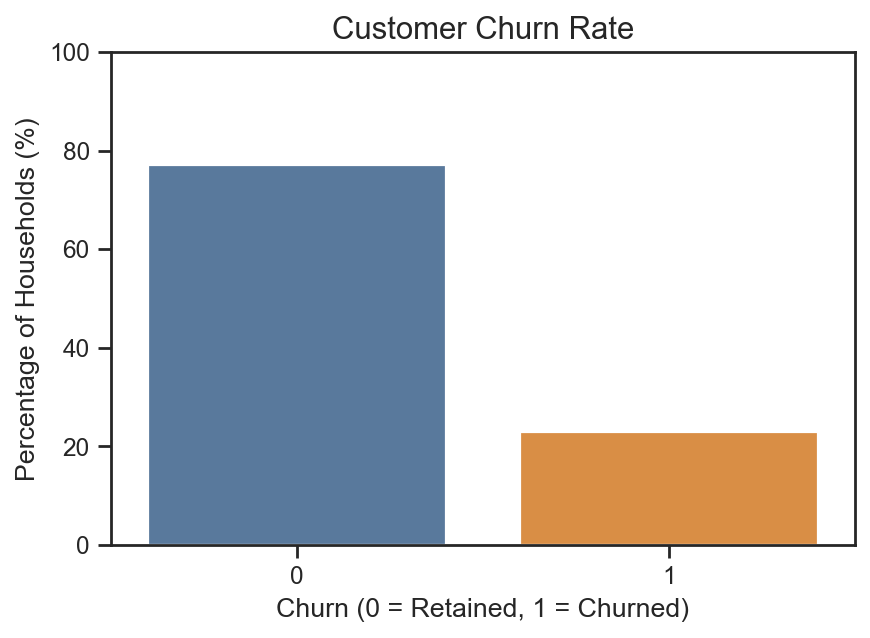

In [5]:
eda.plot_churn_rate(churn_train, colours)

## Demographics

### Demographics Data Cleaning

In [6]:
demographics_train, demographics_valid, demographics_test = eda.clean_demographics(eda.demographics)
ordinal_categorical_demographics = ['age', 'income', 'household_size', 'kids_count']
nominal_categorical_demographics = ['household_comp']
categorical_demographics = ordinal_categorical_demographics + nominal_categorical_demographics

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   household_id    801 non-null    int64 
 1   age             801 non-null    object
 2   income          801 non-null    object
 3   home_ownership  568 non-null    object
 4   marital_status  664 non-null    object
 5   household_size  801 non-null    object
 6   household_comp  801 non-null    object
 7   kids_count      801 non-null    object
dtypes: int64(1), object(7)
memory usage: 50.2+ KB
household_id        0
age                 0
income              0
home_ownership    233
marital_status    137
household_size      0
household_comp      0
kids_count          0
dtype: int64
Number of duplicate rows: 0

AGE - Unique Values:
['65+' '45-54' '35-44' '25-34' '55-64' '19-24']

INCOME - Unique Values:
['35-49K' '50-74K' '25-34K' '15-24K' 'Under 15K' '75-99K' '100-124K'
 '125-149K' '150-174K' '

Considering the amount of missing values in home_ownership and marital status, and the fact that they most likely don't have much informative data on customer churn, we remove these columns from the dataset. 

In [7]:
print(demographics_train.head())
print(demographics_valid.head())
print(demographics_test.head())
print(80*"=")
print(f"Training datapoints: {demographics_train.shape[0]}")
print(f"Validation datapoints: {demographics_valid.shape[0]}")
print(f"Test datapoints: {demographics_test.shape[0]}")

                age     income household_size    household_comp kids_count
household_id                                                              
1               65+     35-49K              2  2 Adults No Kids          0
1001          45-54     50-74K              1   1 Adult No Kids          0
1003          35-44     25-34K              1   1 Adult No Kids          0
1004          25-34     15-24K              1   1 Adult No Kids          0
101           45-54  Under 15K              4     2 Adults Kids          2
                age     income household_size    household_comp kids_count
household_id                                                              
1024          25-34  Under 15K              4     2 Adults Kids          2
1070          35-44     50-74K              2  2 Adults No Kids          0
113           35-44   125-149K              4     2 Adults Kids          2
1135          45-54     50-74K              2      1 Adult Kids          1
1137            65+     3

### Demographics Visualisation

(<Figure size 960x480 with 5 Axes>,
 array([[<Axes: title={'center': 'age'}>,
         <Axes: title={'center': 'income'}>,
         <Axes: title={'center': 'household_size'}>],
        [<Axes: title={'center': 'kids_count'}>,
         <Axes: title={'center': 'household_comp'}>, <Axes: >]],
       dtype=object))

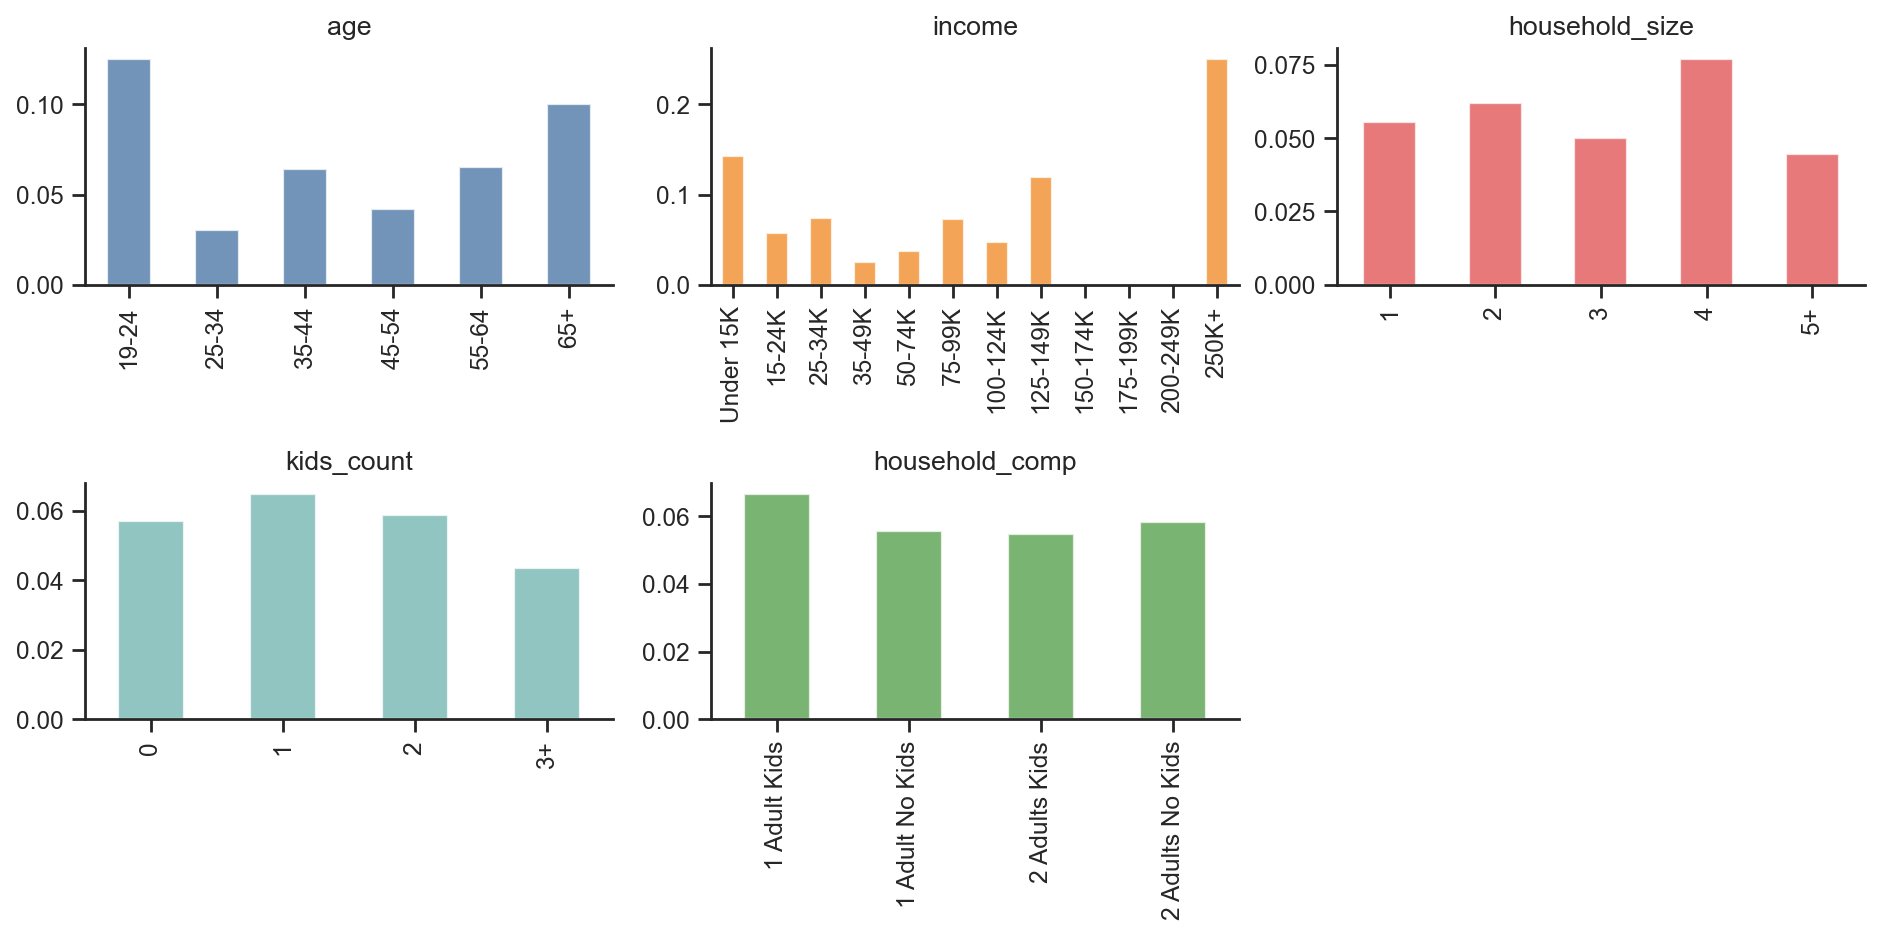

In [8]:
# Run Cleaned Demographics EDA function for variables to be defined
income_order = ['Under 15K', '15-24K', '25-34K', '35-49K', '50-74K', 
                '75-99K', '100-124K', '125-149K', '150-174K', '175-199K', 
                '200-249K', '250K+']
churn_demographics_train = churn_train.loc[demographics_train.index]
eda.crosstabplots(demographics_train[categorical_demographics], churn_demographics_train, {'income': income_order})

(<Figure size 1200x640 with 5 Axes>,
 array([<Axes: title={'center': 'age'}, ylabel='N households'>,
        <Axes: title={'center': 'income'}, ylabel='N households'>,
        <Axes: title={'center': 'household_size'}, ylabel='N households'>,
        <Axes: title={'center': 'kids_count'}, ylabel='N households'>,
        <Axes: title={'center': 'household_comp'}, ylabel='N households'>,
        <Axes: >], dtype=object))

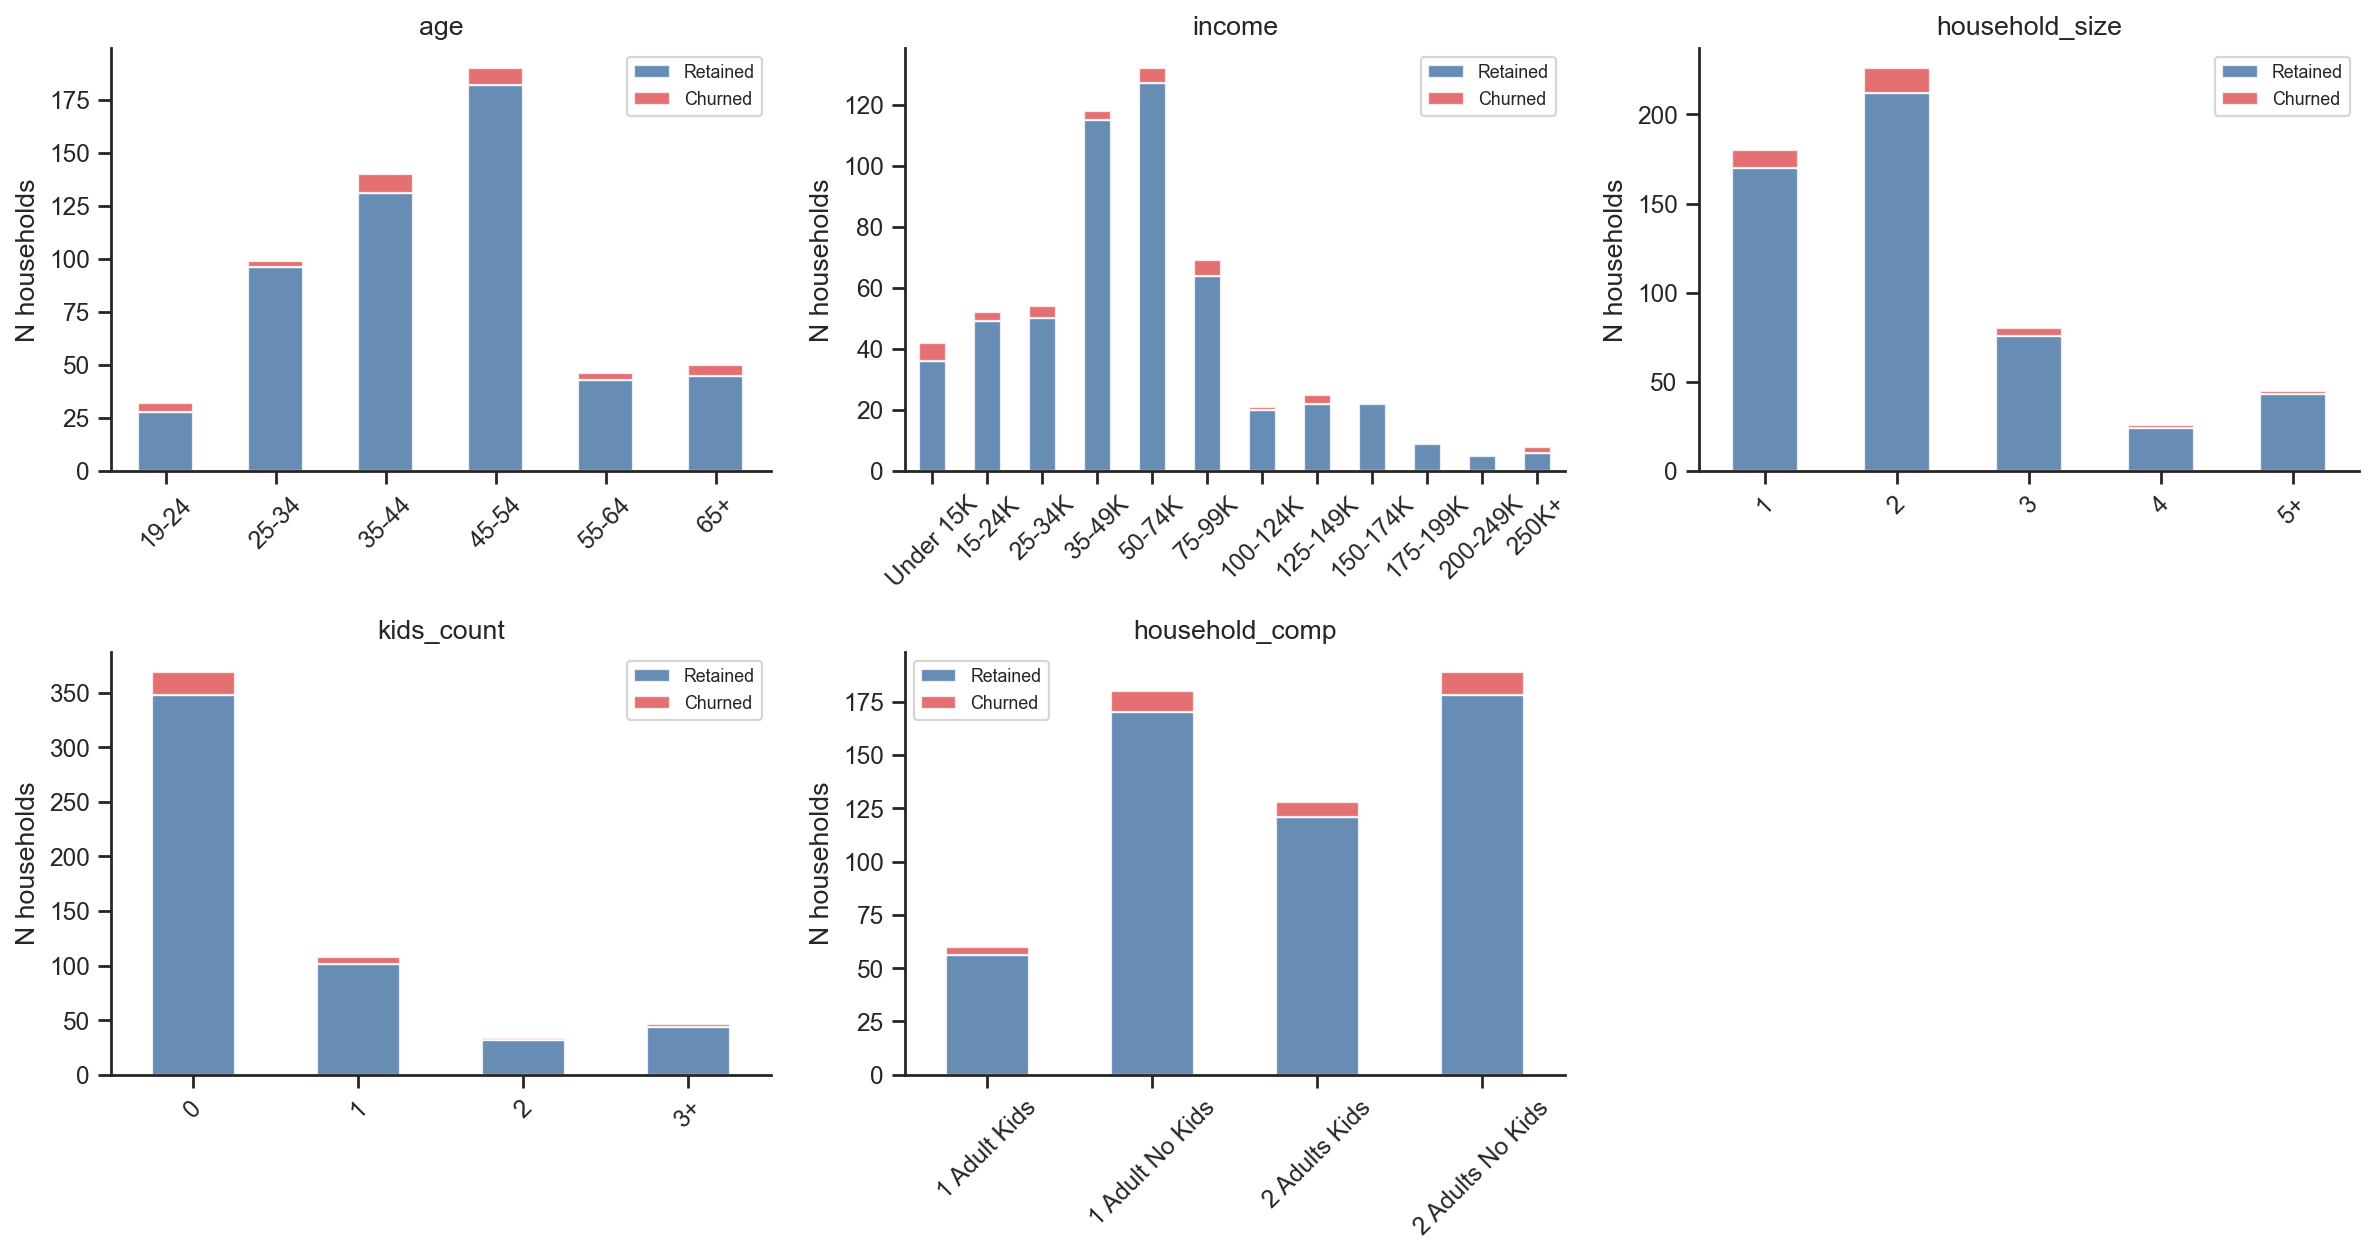

In [9]:
eda.churn_stack_plot(demographics_train[categorical_demographics], churn_demographics_train, column_orders={'income': income_order})

In [10]:
demographics_train['income'], demographics_valid['income'], demographics_test['income'] = feature_eng.collapse_income_categories(demographics_train, demographics_valid, demographics_test)
print(demographics_train['income'].value_counts())

income
50-74K       132
35-49K       118
100K+         90
75-99K        69
25-34K        54
15-24K        52
Under 15K     42
Name: count, dtype: int64


(<Figure size 960x480 with 5 Axes>,
 array([[<Axes: title={'center': 'age'}>,
         <Axes: title={'center': 'income'}>,
         <Axes: title={'center': 'household_size'}>],
        [<Axes: title={'center': 'kids_count'}>,
         <Axes: title={'center': 'household_comp'}>, <Axes: >]],
       dtype=object))

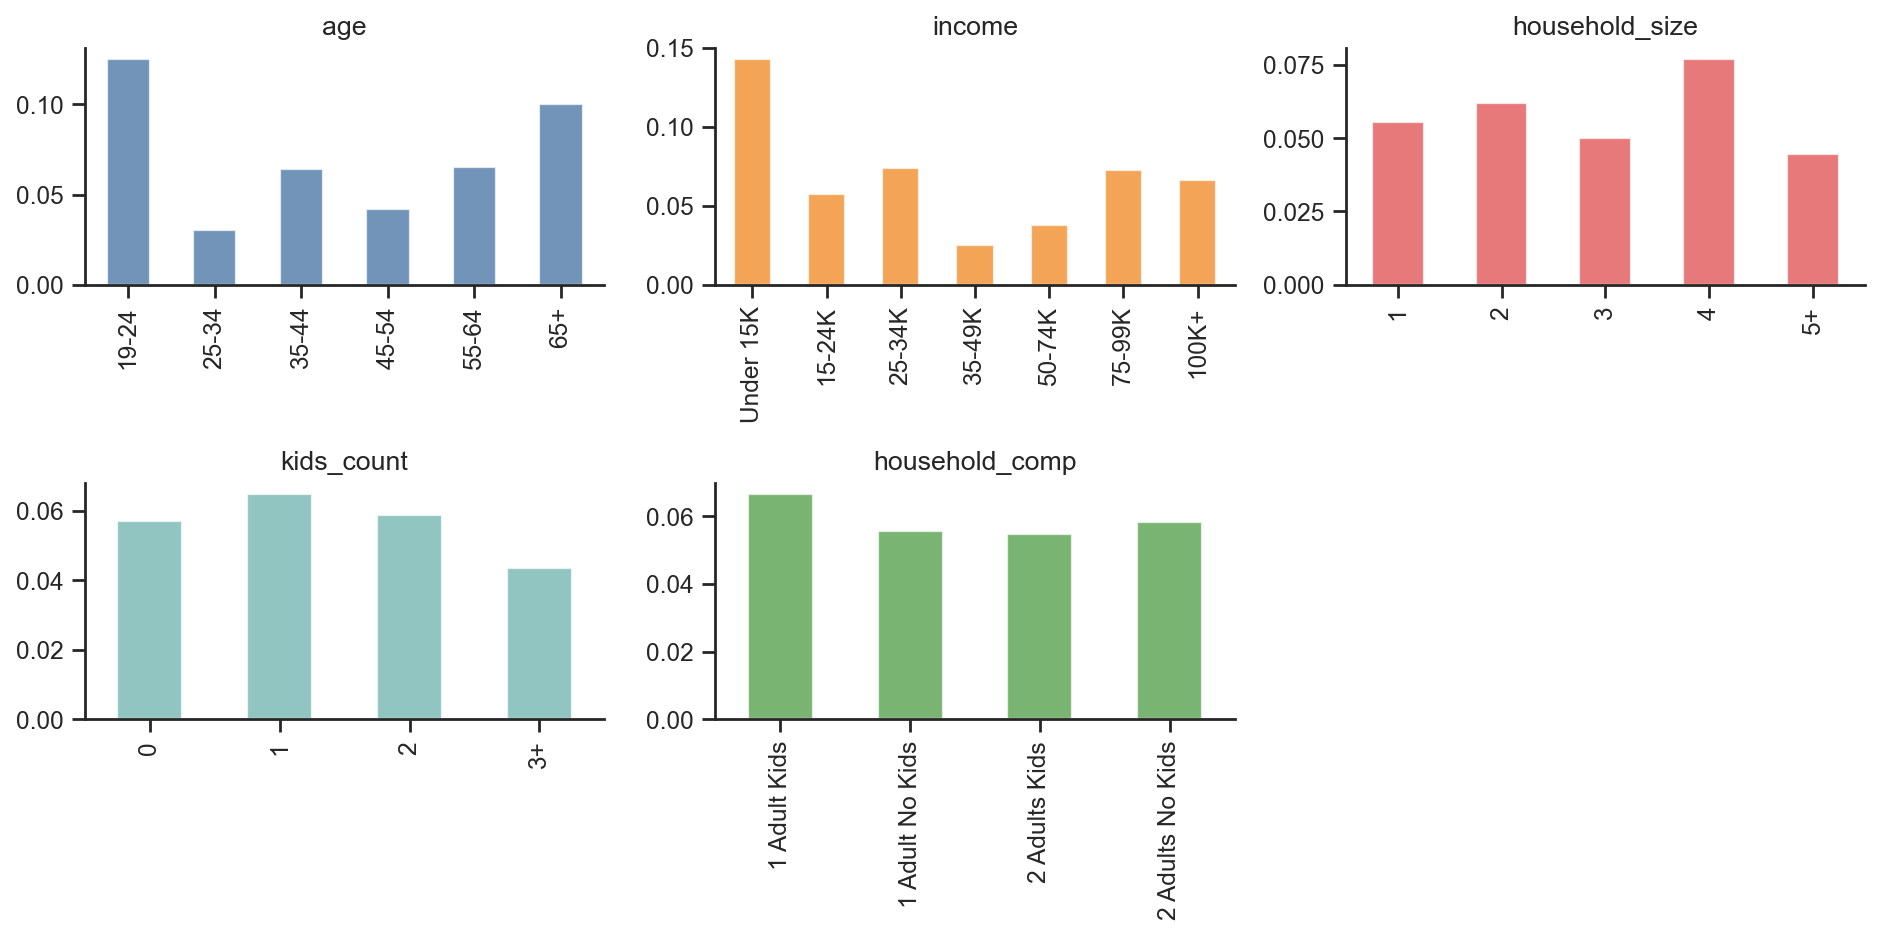

In [11]:
income_order = ['Under 15K', '15-24K', '25-34K', '35-49K', '50-74K', 
                '75-99K', '100K+']
eda.crosstabplots(demographics_train[categorical_demographics], churn_demographics_train, {'income': income_order})

(<Figure size 1200x640 with 5 Axes>,
 array([<Axes: title={'center': 'age'}, ylabel='N households'>,
        <Axes: title={'center': 'income'}, ylabel='N households'>,
        <Axes: title={'center': 'household_size'}, ylabel='N households'>,
        <Axes: title={'center': 'kids_count'}, ylabel='N households'>,
        <Axes: title={'center': 'household_comp'}, ylabel='N households'>,
        <Axes: >], dtype=object))

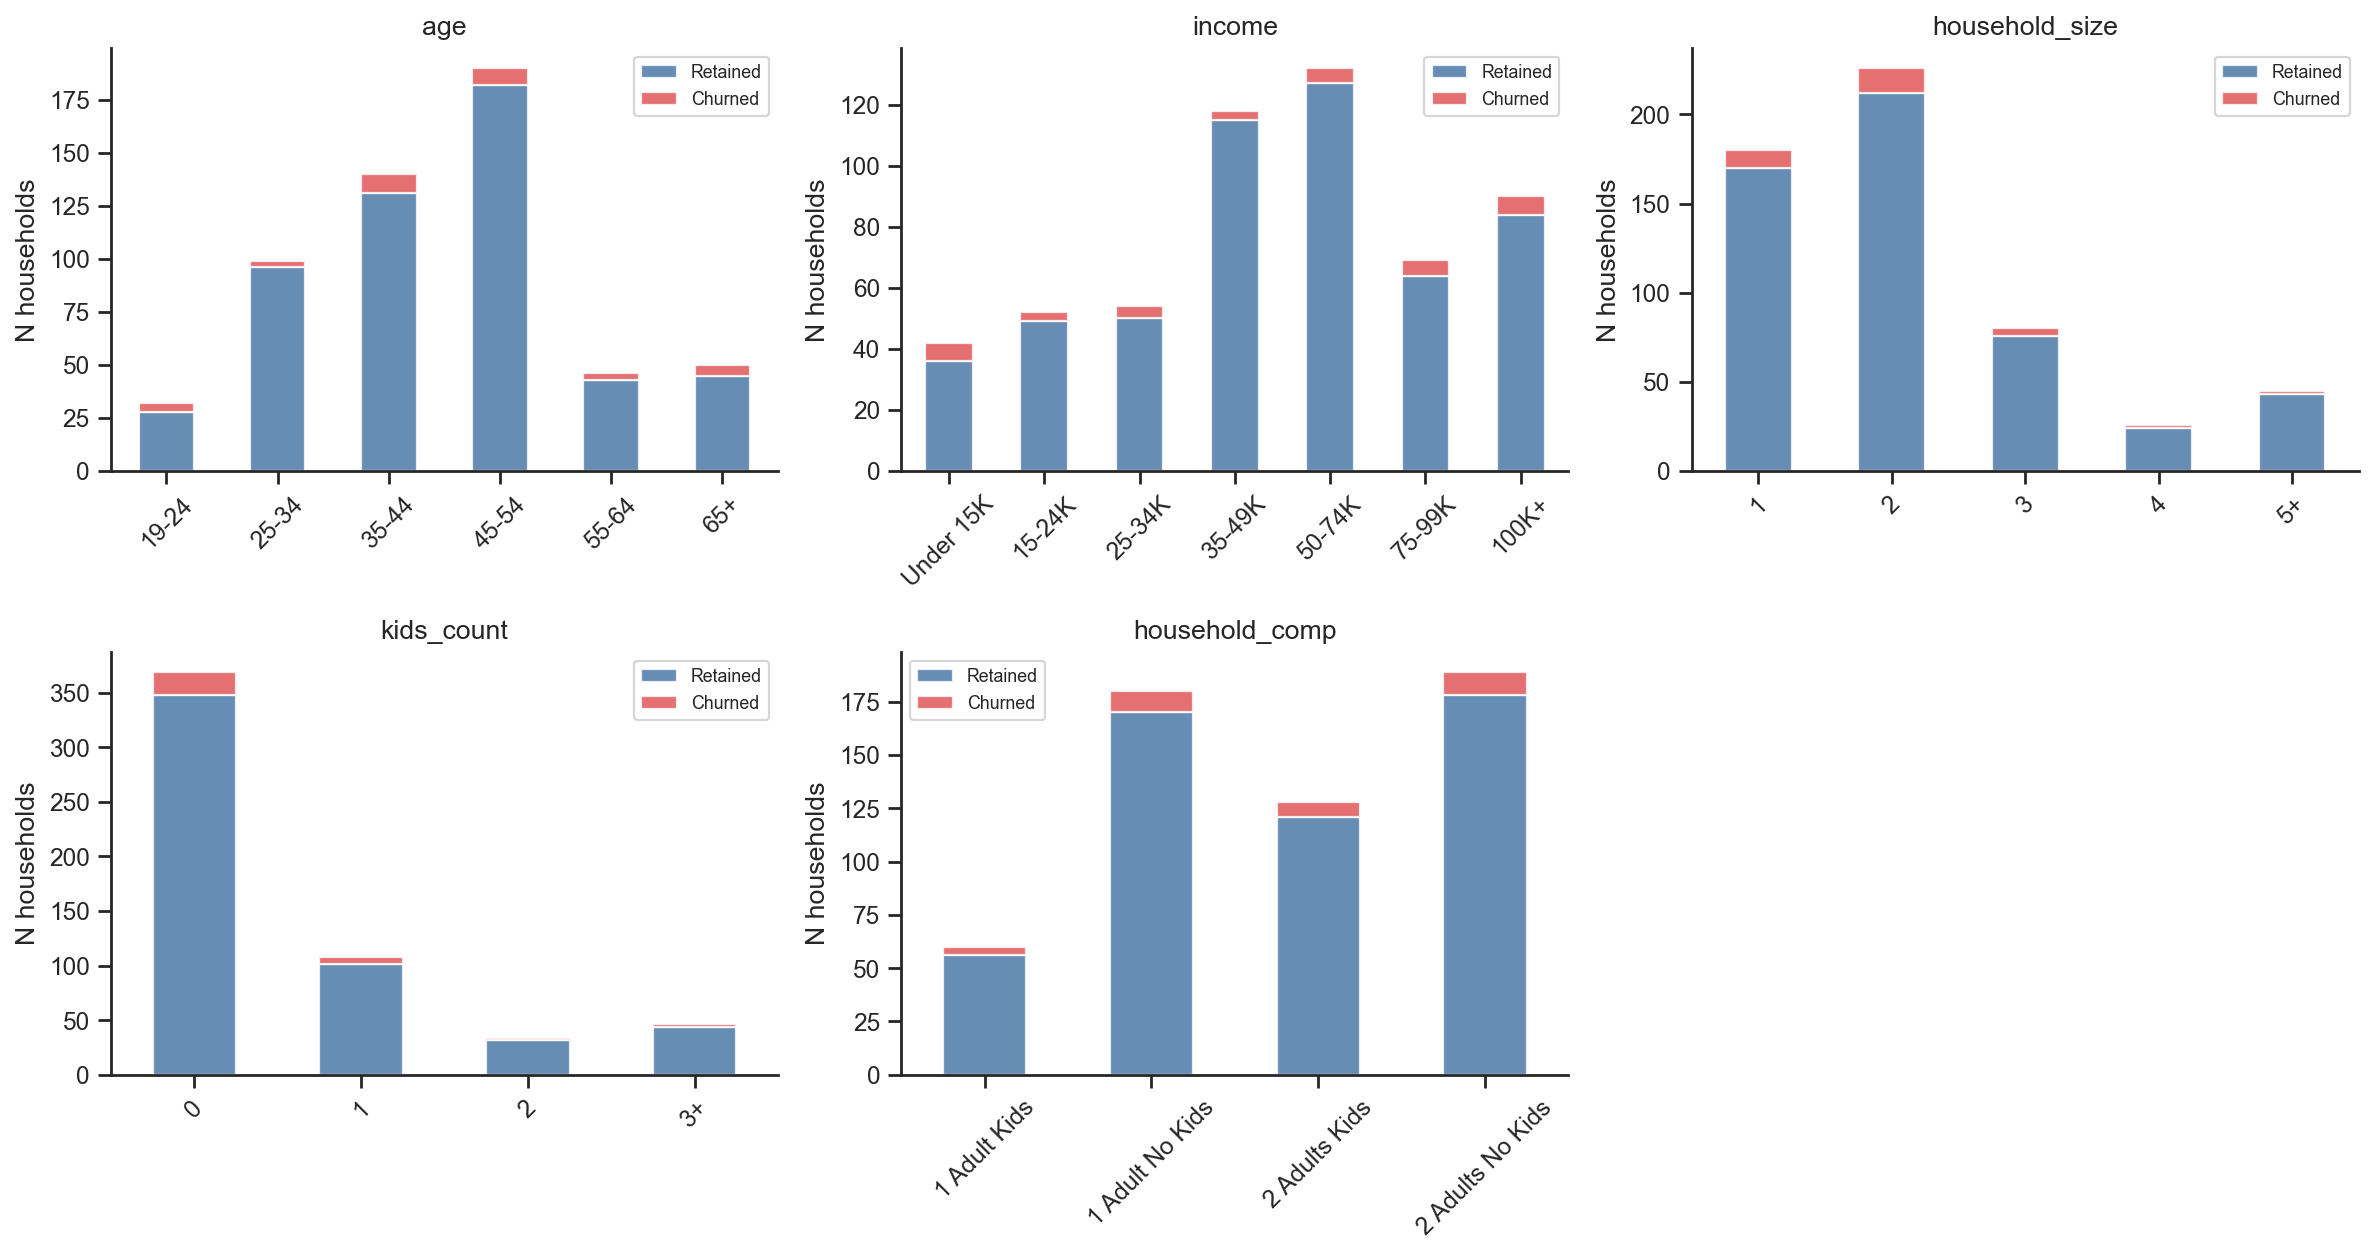

In [12]:
eda.churn_stack_plot(demographics_train[categorical_demographics], churn_demographics_train, column_orders={'income': income_order})

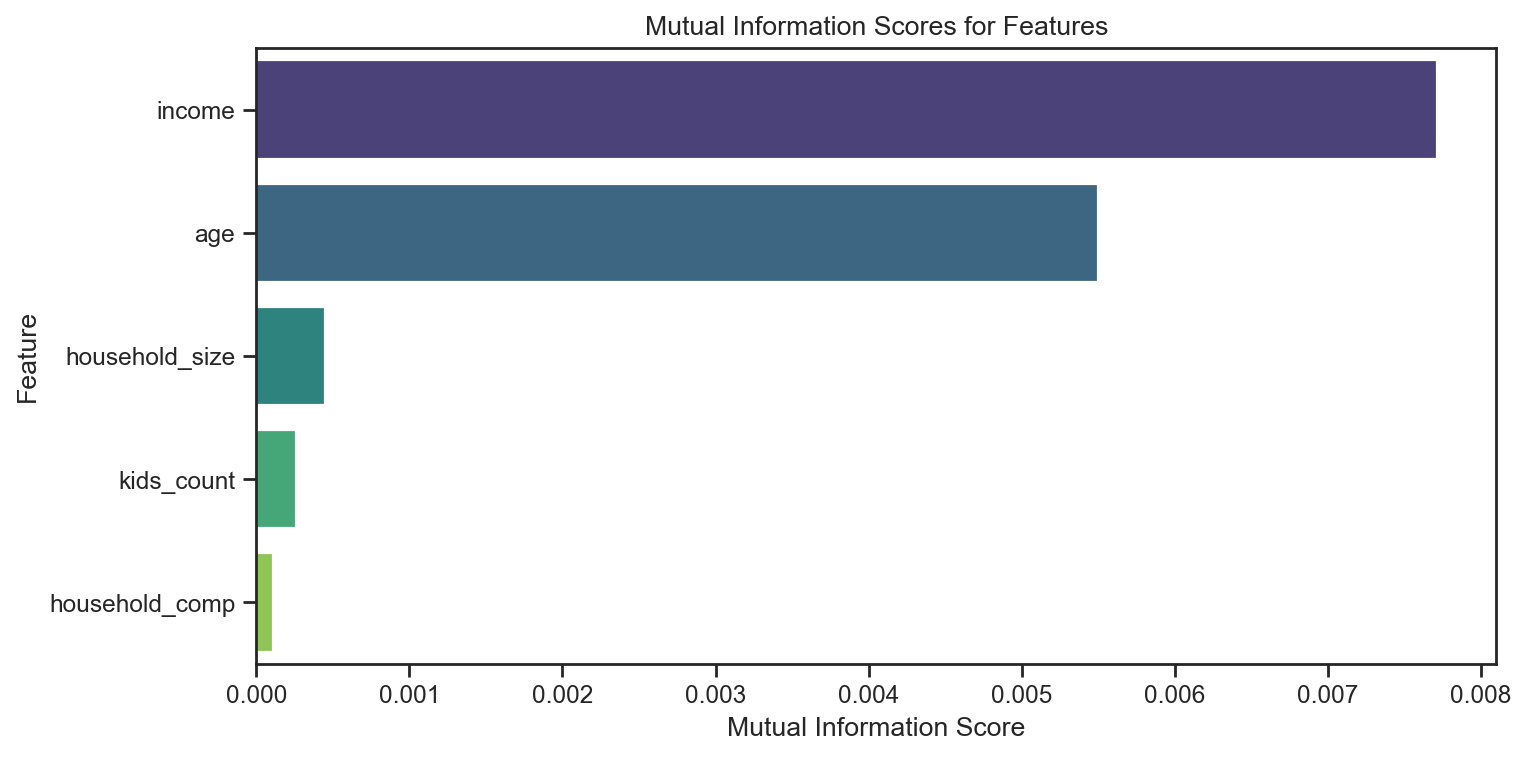

,MI
income,0.007716
age,0.005499
household_size,0.000446
kids_count,0.000258
household_comp,0.000110


In [13]:
eda.mutual_information_table(demographics_train, categorical=categorical_demographics, target=churn_demographics_train)

## Transactions

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1469307 entries, 0 to 1469306
Data columns (total 11 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   household_id           1469307 non-null  int64         
 1   store_id               1469307 non-null  int64         
 2   basket_id              1469307 non-null  int64         
 3   product_id             1469307 non-null  int64         
 4   quantity               1469307 non-null  int64         
 5   sales_value            1469307 non-null  float64       
 6   retail_disc            1469307 non-null  float64       
 7   coupon_disc            1469307 non-null  float64       
 8   coupon_match_disc      1469307 non-null  float64       
 9   week                   1469307 non-null  int64         
 10  transaction_timestamp  1469307 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(4), int64(6)
memory usage: 123.3 MB
Missing values in trans

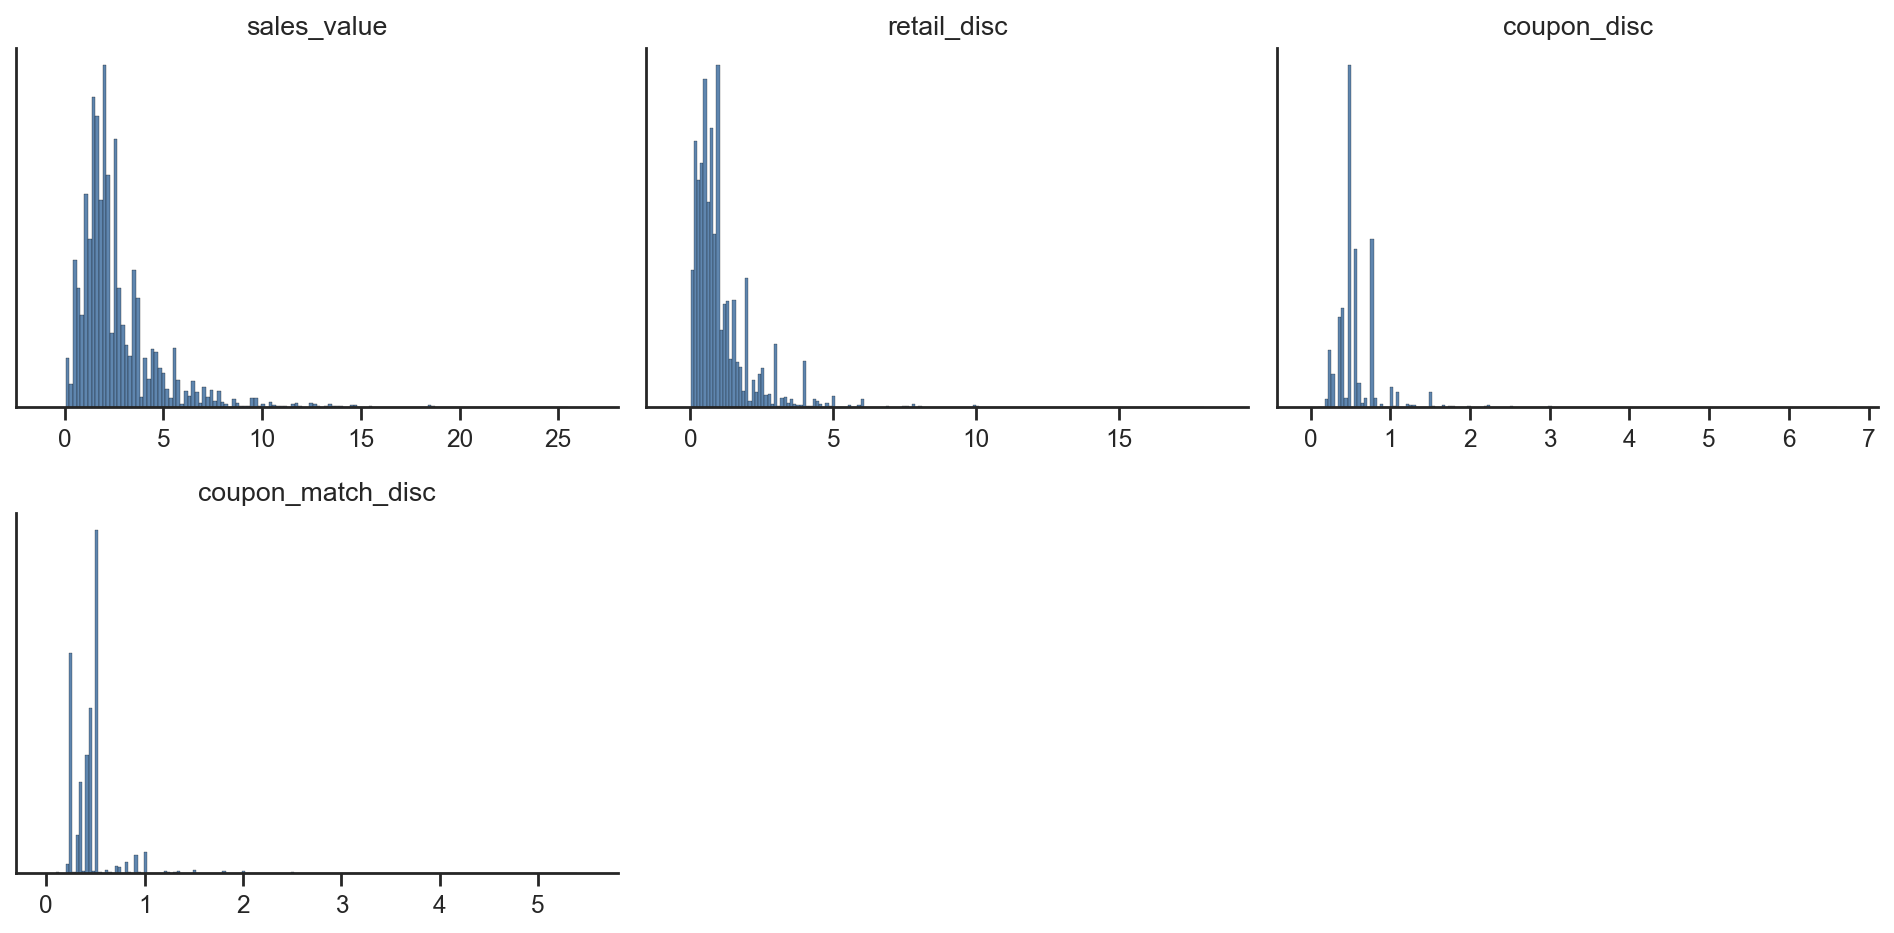

In [77]:
transactions_train, transactions_valid, transactions_test = eda.clean_transactions(eda.transactions)
print(eda.plot_transactions(eda.transactions))


(<Figure size 960x240 with 3 Axes>,
 array([<Axes: title={'center': 'Total Spend'}>,
        <Axes: title={'center': 'Transaction Frequency'}>,
        <Axes: title={'center': 'Avg Basket Size'}>], dtype=object))

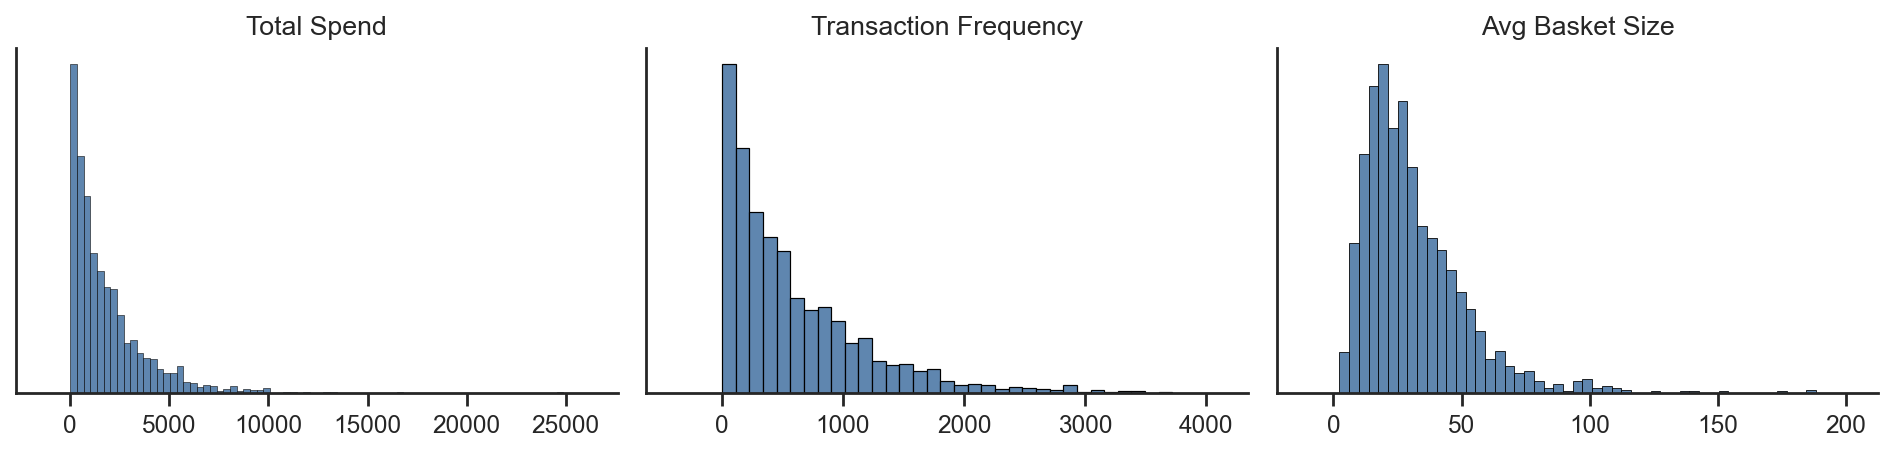

In [15]:
# Create total spend feature and split into train/valid/test
total_spend = feature_eng.total_spend(transactions)
total_spend_train = total_spend[total_spend.index.isin(transactions_train['household_id'])]
total_spend_valid = total_spend[total_spend.index.isin(transactions_valid['household_id'])]
total_spend_test  = total_spend[total_spend.index.isin(transactions_test['household_id'])]

#Create transaction frequency feature and split into train/valid/test
transaction_frequency = feature_eng.transaction_frequency(transactions)
transaction_frequency_train = transaction_frequency[transaction_frequency.index.isin(transactions_train['household_id'])]
transaction_frequency_valid = transaction_frequency[transaction_frequency.index.isin(transactions_valid['household_id'])]
transaction_frequency_test  = transaction_frequency[transaction_frequency.index.isin(transactions_test['household_id'])]

# Create average basket size feature and split into train/valid/test
average_basket_size = feature_eng.average_basket_size(transactions)
average_basket_size_train = average_basket_size[average_basket_size.index.isin(transactions_train['household_id'])]
average_basket_size_valid = average_basket_size[average_basket_size.index.isin(transactions_valid['household_id'])]
average_basket_size_test  = average_basket_size[average_basket_size.index.isin(transactions_test['household_id'])]

customer_features = pd.DataFrame({
    'Total Spend': total_spend_train,
    'Transaction Frequency': transaction_frequency_train,
    'Avg Basket Size': average_basket_size_train
})

eda.distplots(customer_features)

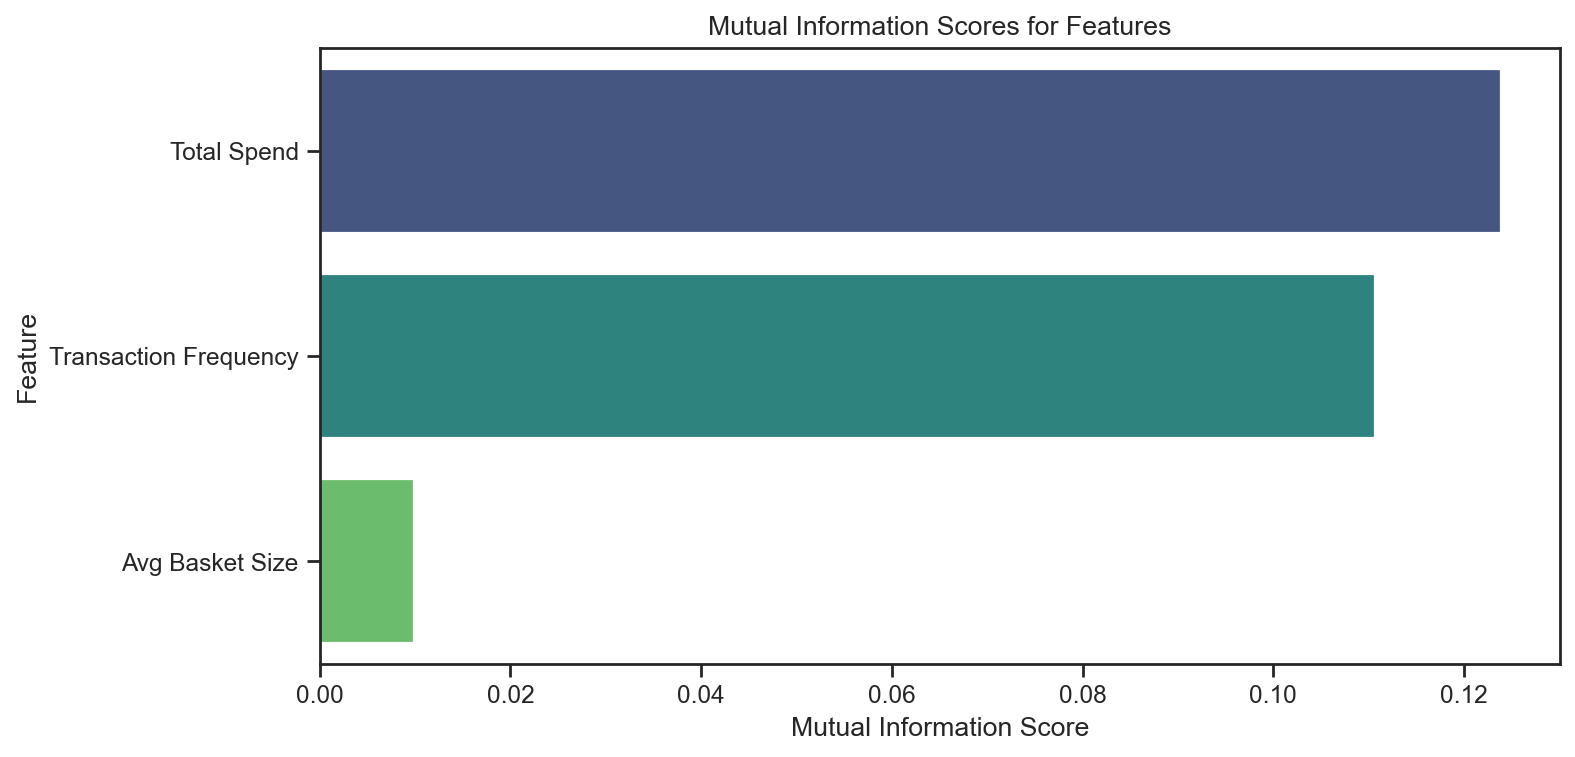

,MI
Total Spend,0.123842
Transaction Frequency,0.110611
Avg Basket Size,0.009934


In [16]:
eda.mutual_information_table(customer_features, target=churn_train, continuous= ['Total Spend', 'Transaction Frequency', 'Avg Basket Size'])

(<Figure size 960x240 with 3 Axes>,
 array([<Axes: title={'center': 'Total Spend'}>,
        <Axes: title={'center': 'Transaction Frequency'}>,
        <Axes: title={'center': 'Avg Basket Size'}>], dtype=object))

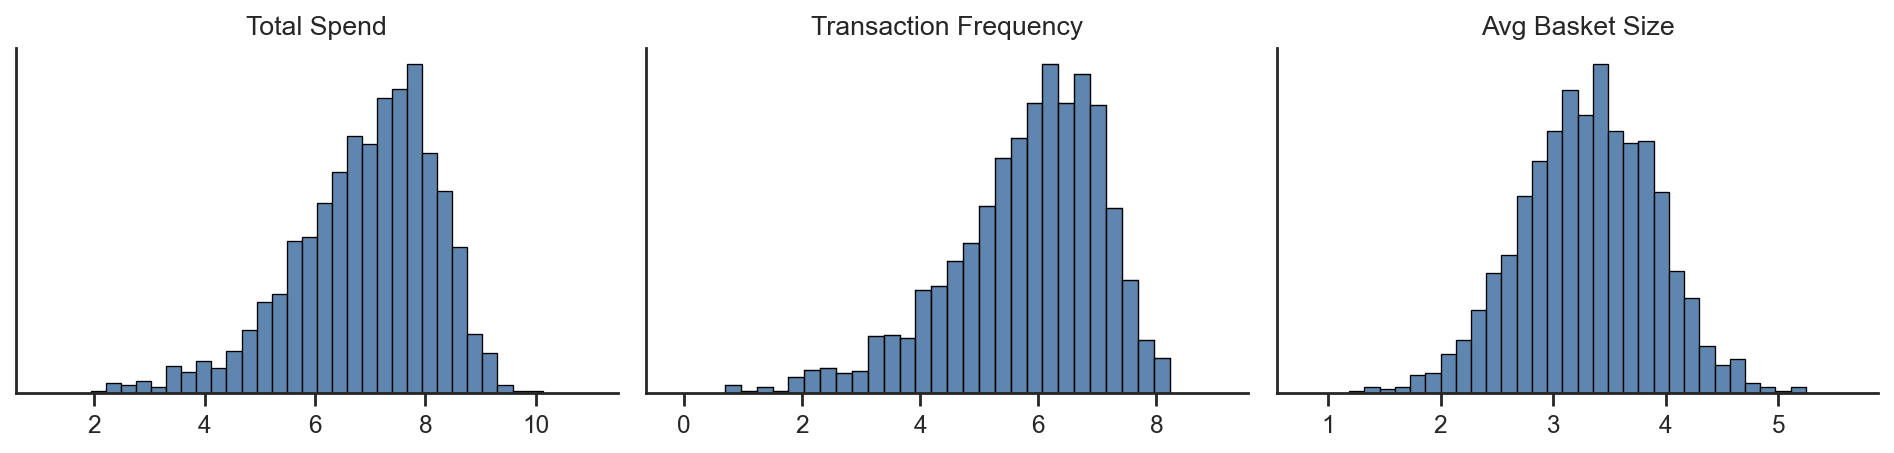

In [17]:
log_total_spend_train = np.log1p(total_spend_train)
log_total_spend_valid = np.log1p(total_spend_valid)
log_total_spend_test  = np.log1p(total_spend_test)

log_transaction_frequency_train = np.log1p(transaction_frequency_train)
log_transaction_frequency_valid = np.log1p(transaction_frequency_valid)
log_transaction_frequency_test  = np.log1p(transaction_frequency_test)

log_average_basket_size_train = np.log1p(average_basket_size_train)
log_average_basket_size_valid = np.log1p(average_basket_size_valid)
log_average_basket_size_test  = np.log1p(average_basket_size_test)

log_customer_features = pd.DataFrame({
    'Total Spend': log_total_spend_train,
    'Transaction Frequency': log_transaction_frequency_train,
    'Avg Basket Size': log_average_basket_size_train
})

eda.distplots(log_customer_features)


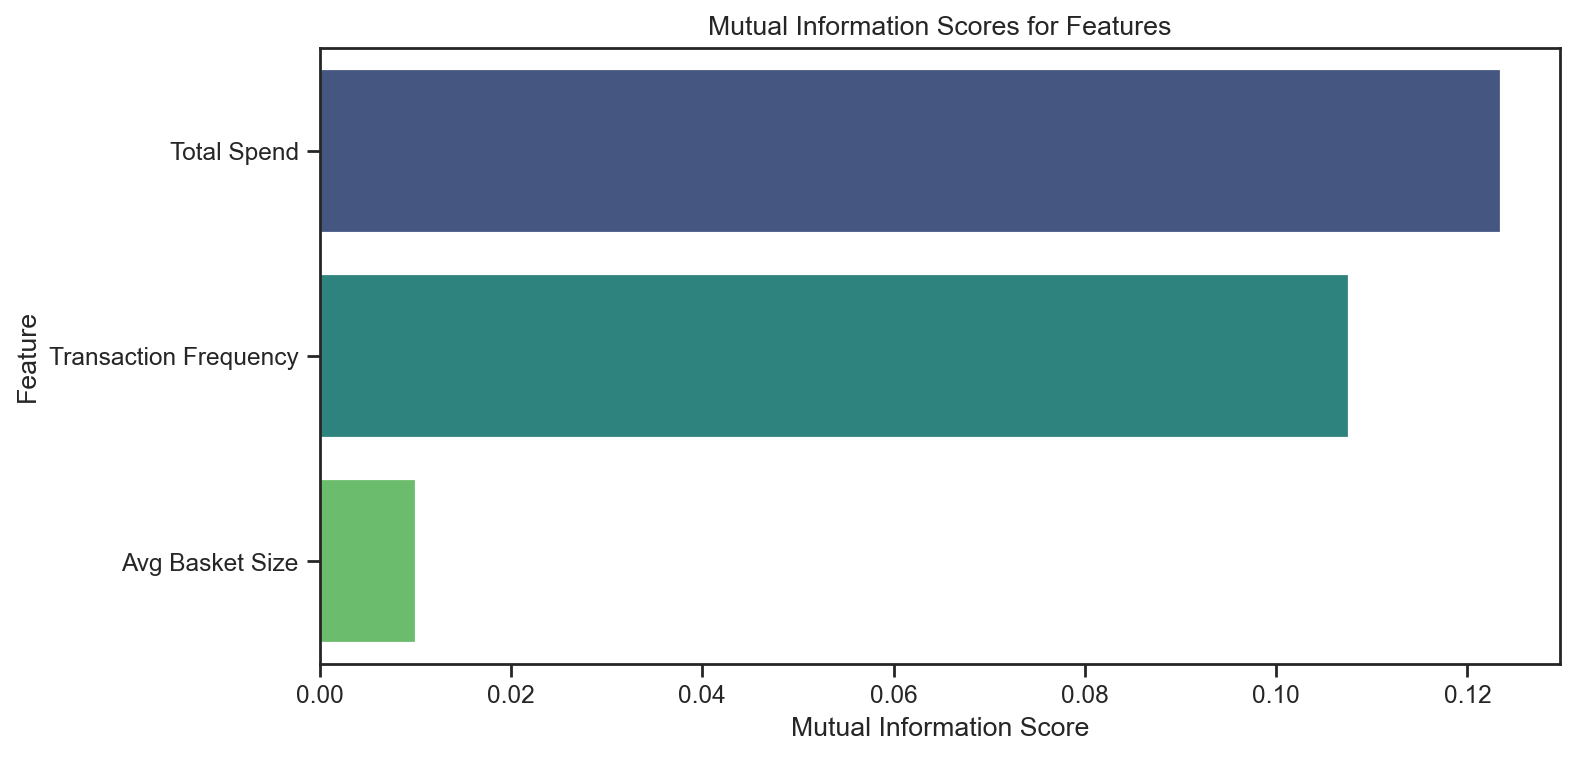

,MI
Total Spend,0.123477
Transaction Frequency,0.107595
Avg Basket Size,0.010081


In [18]:
eda.mutual_information_table(log_customer_features, target=churn_train, continuous= ['Total Spend', 'Transaction Frequency', 'Avg Basket Size'])

              spend_trend
household_id             
1               -0.408982
2                0.000000
3                0.000000
4                0.000000
6               -0.350644
...                   ...
2496            -0.678478
2497            -0.194435
2498            -0.470425
2499            -0.709088
2500            -0.215101

[2227 rows x 1 columns]
spend_trend shape: (2227, 1)
churn_aligned shape: (2227,)


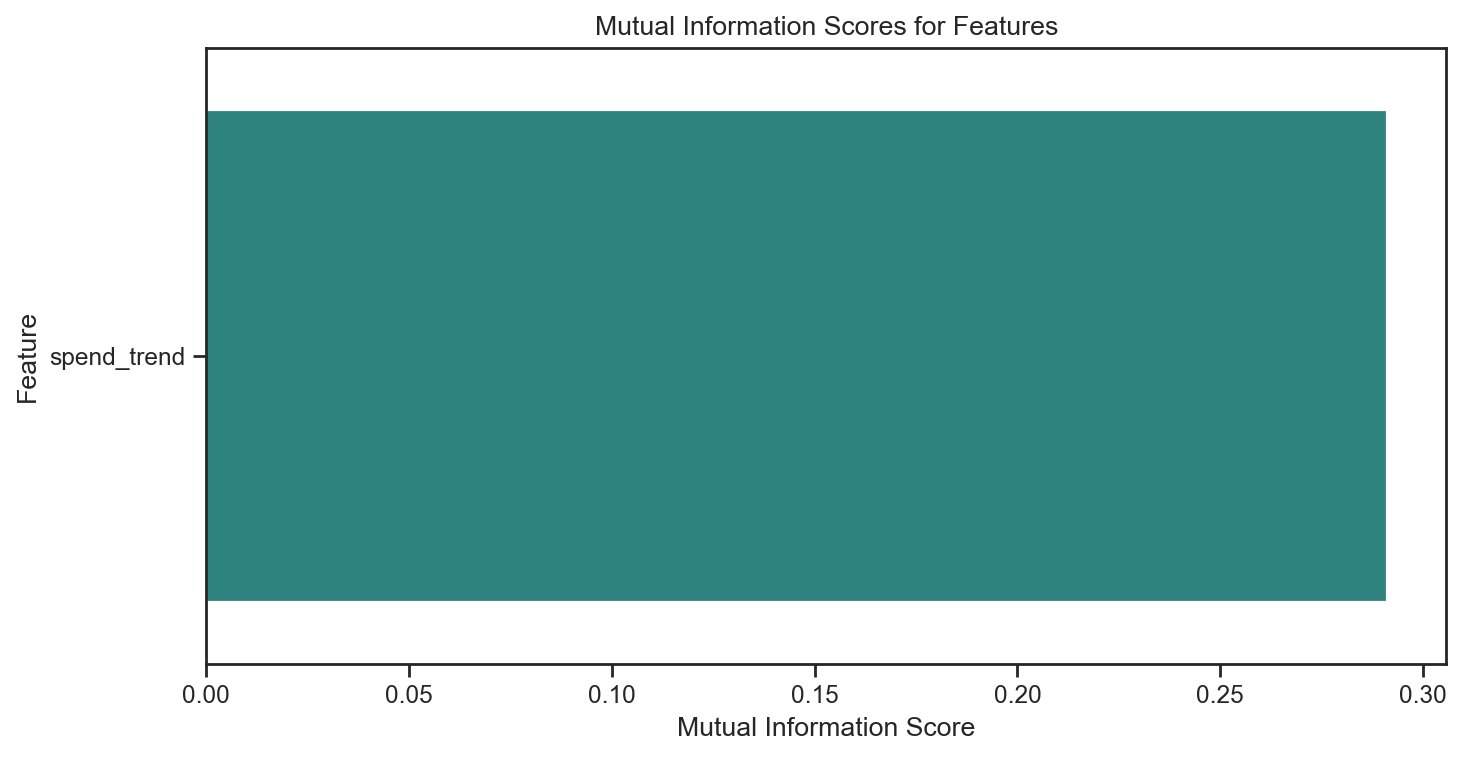

,MI
spend_trend,0.29116


In [19]:
# SPLIT INTO TRAINING BEFORE FEATURE ENGINEERING TO AVOID DATA LEAKAGE
spend_trend = feature_eng.spend_trend(eda.transactions)
print(spend_trend)

# Align churn with spend_trend (filter to matching households)
churn_aligned = churn[churn.index.isin(spend_trend.index)]
print(f"spend_trend shape: {spend_trend.shape}")
print(f"churn_aligned shape: {churn_aligned.shape}")

# Plot spend trend vs churn using mutual information
eda.mutual_information_table(spend_trend, target=churn_aligned, continuous=list(spend_trend.columns))

In [20]:
eda.compare_customer_features_by_churn(log_customer_features, churn_train)

COMPARISON OF CUSTOMER FEATURES BY CHURN STATUS (Original Scale)

                 Feature  Churn_0_Original  Churn_1_Original  Percent_Difference  T_PValue
0            Total Spend       1411.618001        313.065009          -77.822257       0.0
1  Transaction Frequency        460.139223        101.319472          -77.980692       0.0
2        Avg Basket Size         27.190922         23.356530          -14.101734       0.0


Statistically Significant Differences (p < 0.05):
                 Feature  Percent_Difference  T_PValue
0            Total Spend          -77.822257       0.0
1  Transaction Frequency          -77.980692       0.0
2        Avg Basket Size          -14.101734       0.0


## Products

In [21]:
products.head()

,product_id,manufacturer_id,department,brand,product_category,product_type,package_size
0,25671,2,GROCERY,National,FRZN ICE,ICE - CRUSHED/CUBED,22 LB
1,26081,2,MISCELLANEOUS,National,None,None,None
2,26093,69,PASTRY,Private,BREAD,BREAD:ITALIAN/FRENCH,None
3,26190,69,GROCERY,Private,FRUIT - SHELF STABLE,APPLE SAUCE,50 OZ
4,26355,69,GROCERY,Private,COOKIES/CONES,SPECIALTY COOKIES,14 OZ


Probably combine these categories with transactions data to get variables like brand loyalty, department diversity, category repertoire, department level spend or frequency.

In [22]:
eda.clean_products(products)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92331 entries, 0 to 92330
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   product_id        92331 non-null  int64 
 1   manufacturer_id   92331 non-null  int64 
 2   department        92331 non-null  object
 3   brand             92331 non-null  object
 4   product_category  91791 non-null  object
 5   product_type      91803 non-null  object
 6   package_size      61745 non-null  object
dtypes: int64(2), object(5)
memory usage: 4.9+ MB
Missing values in products:  product_id              0
manufacturer_id         0
department              0
brand                   0
product_category      540
product_type          528
package_size        30586
dtype: int64
Number of duplicate rows: 0

Missingness overlap (product_category vs product_type):
type missing  False  True 
cat missing               
False         91692     99
True            111    429

package_si

In [23]:
#Drop because 30% missing and not relevant to churn prediction
products = products.drop(columns=['package_size'])

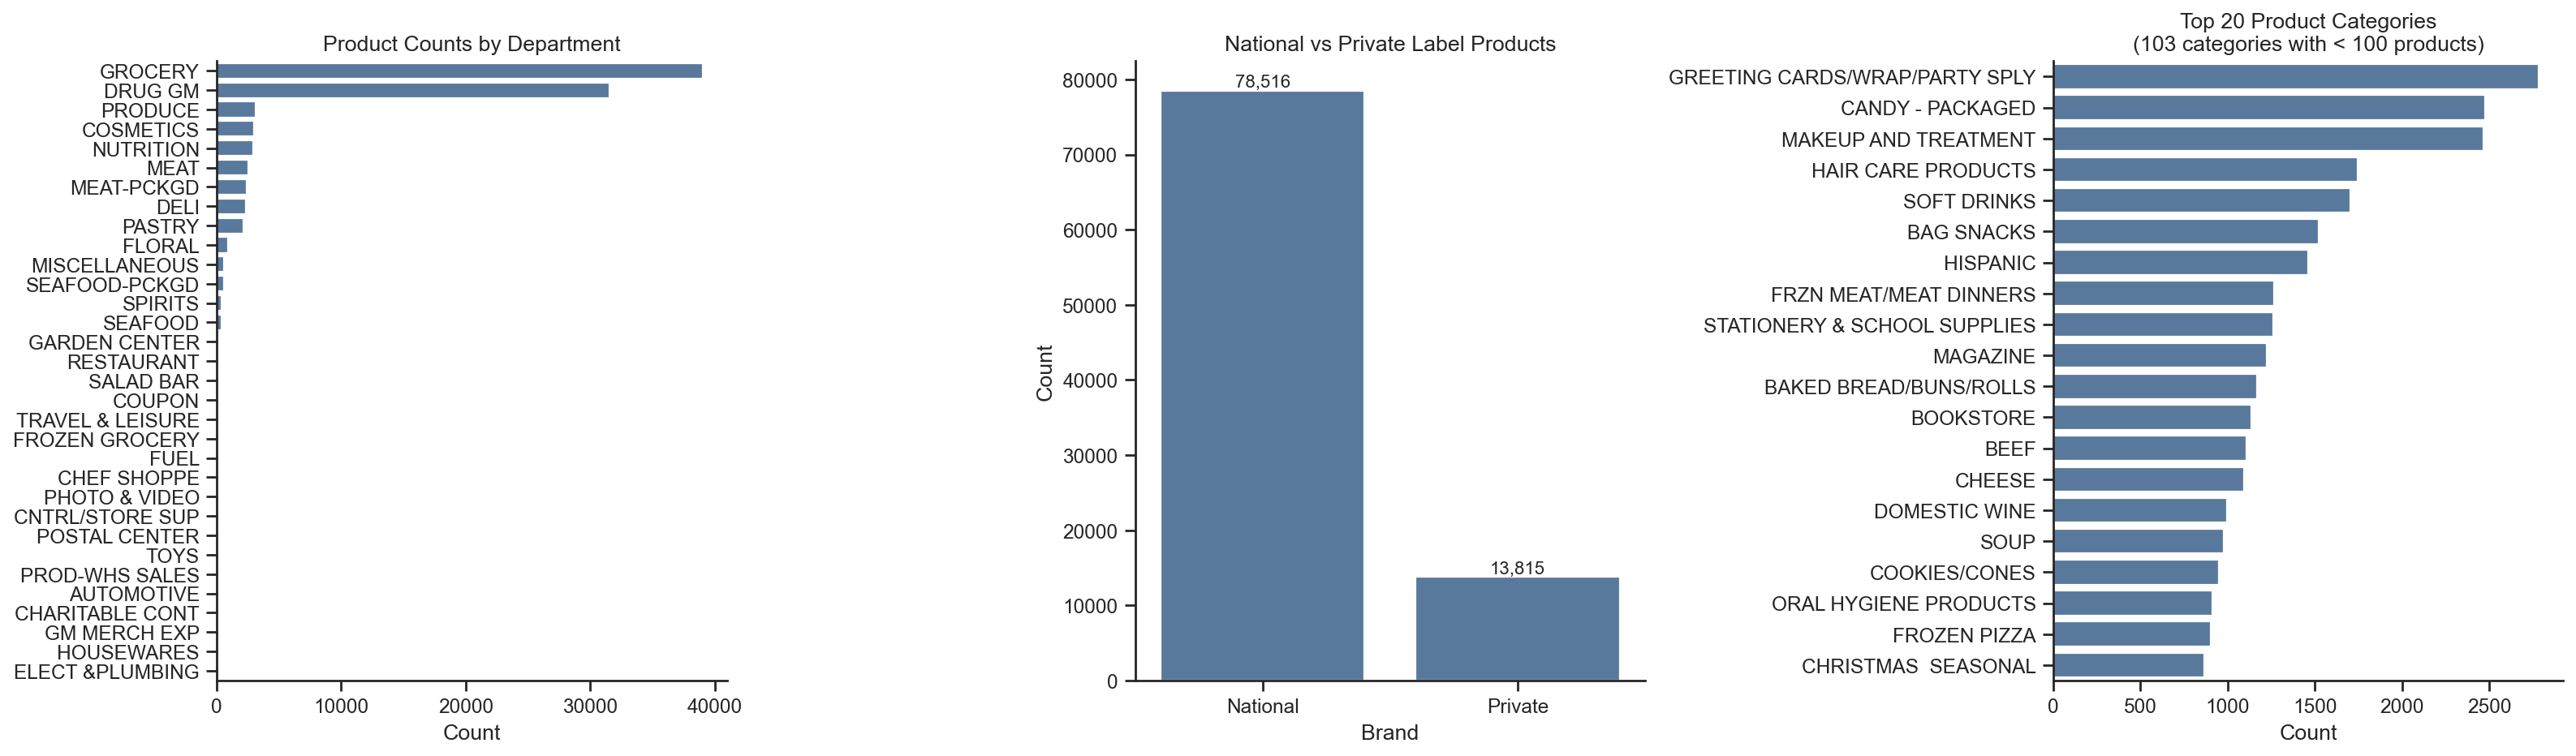


Total categories: 308
Rare categories (< 100 products): 103 (33.4%)

Rare categories:
product_category
FROZEN PACKAGE MEAT        1
EASTER LILY                1
HOUSEWARES                 1
PKG.SEAFOOD MISC           1
MISCELLANEOUS CROUTONS     1
                          ..
TOBACCO OTHER             91
HERBS                     91
FLOUR & MEALS             95
SEAFOOD - MISC            96
VALUE ADDED VEGETABLES    96
Name: count, Length: 103, dtype: int64


In [39]:
eda.plot_products_eda(products, rare_threshold=100)

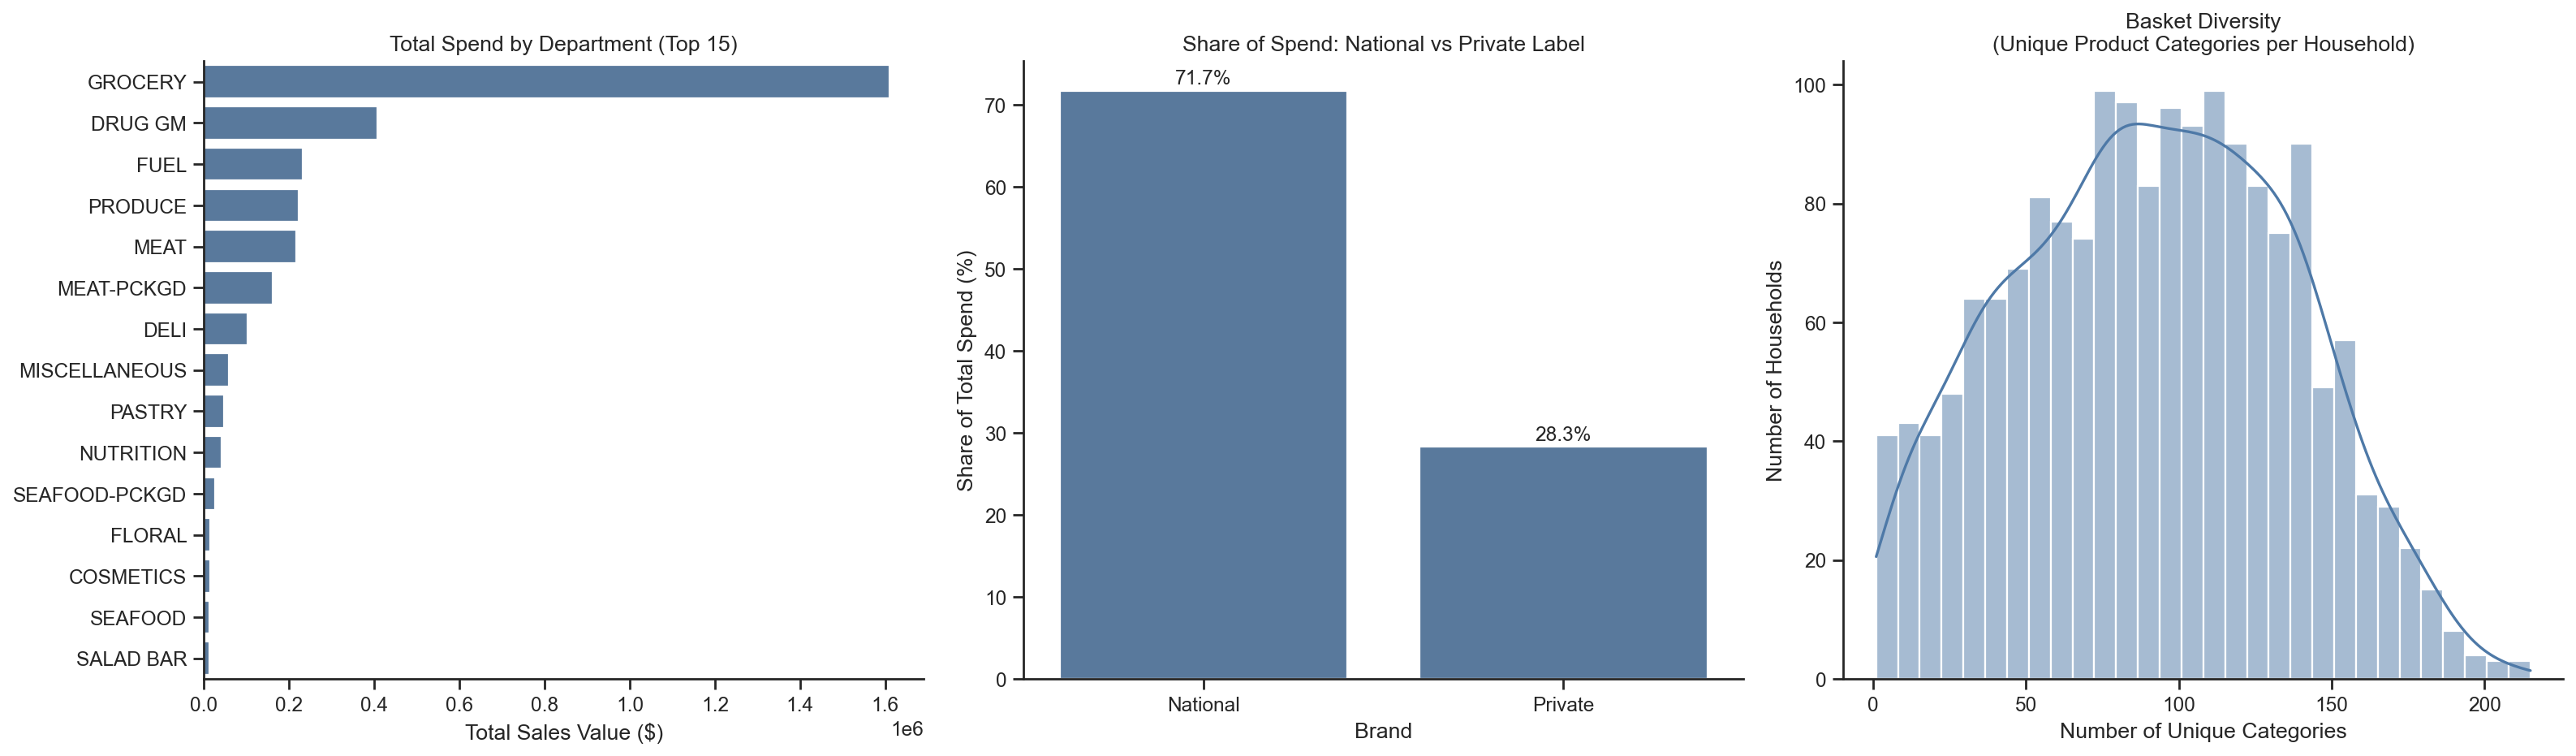

Median basket diversity: 92 unique categories
Mean basket diversity:   91.3 unique categories


In [68]:
eda.plot_spend_by_product_attribute(transactions_train, products)

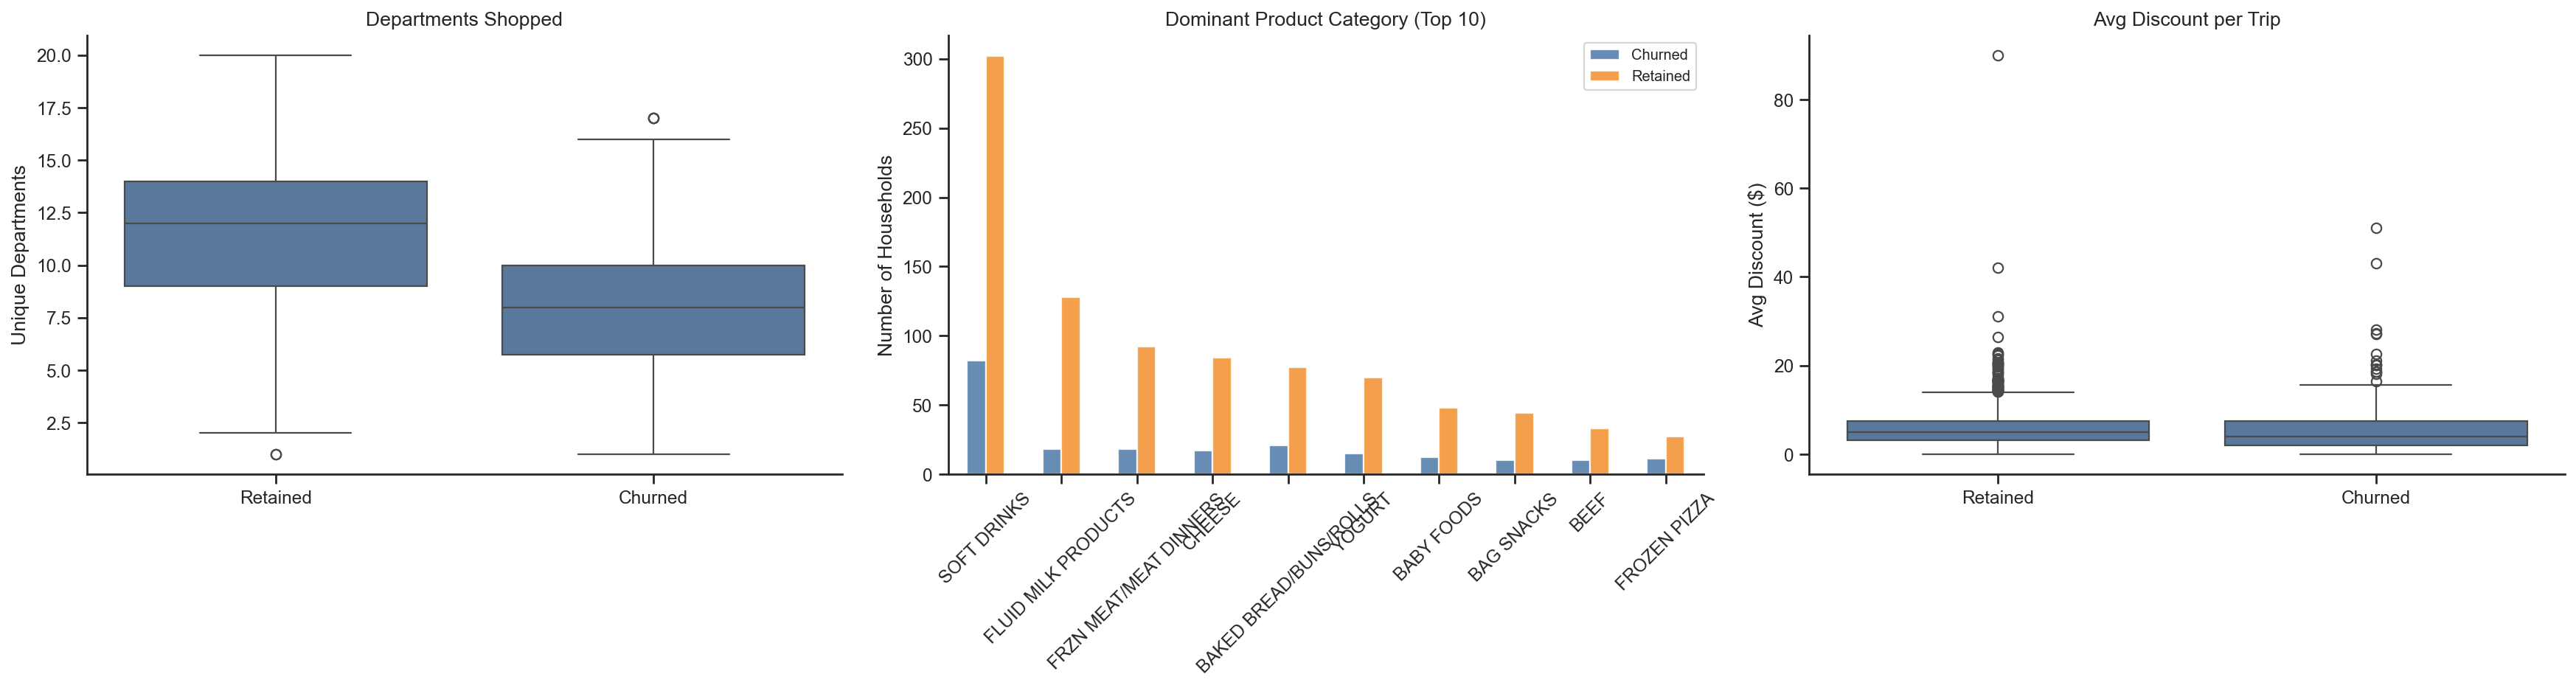

             n_departments  avg_discount_per_trip
churn_label                                      
Churned                8.0                  3.959
Retained              12.0                  4.967


In [64]:
product_features_train = eda.plot_churn_product_features(transactions_train, products, churn_train)

In [79]:
product_features_train.shape[0]

1728

## Campaigns

In [80]:
campaigns_train, campaigns_valid, campaigns_test = eda.clean_campaigns(campaigns)
print(campaigns_train.shape[0])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6589 entries, 0 to 6588
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   campaign_id   6589 non-null   int64
 1   household_id  6589 non-null   int64
dtypes: int64(2)
memory usage: 103.1 KB
Missing values in campaigns:  campaign_id     0
household_id    0
dtype: int64
Number of duplicate rows: 0
4571


Text(0, 0.5, 'Number of Households')

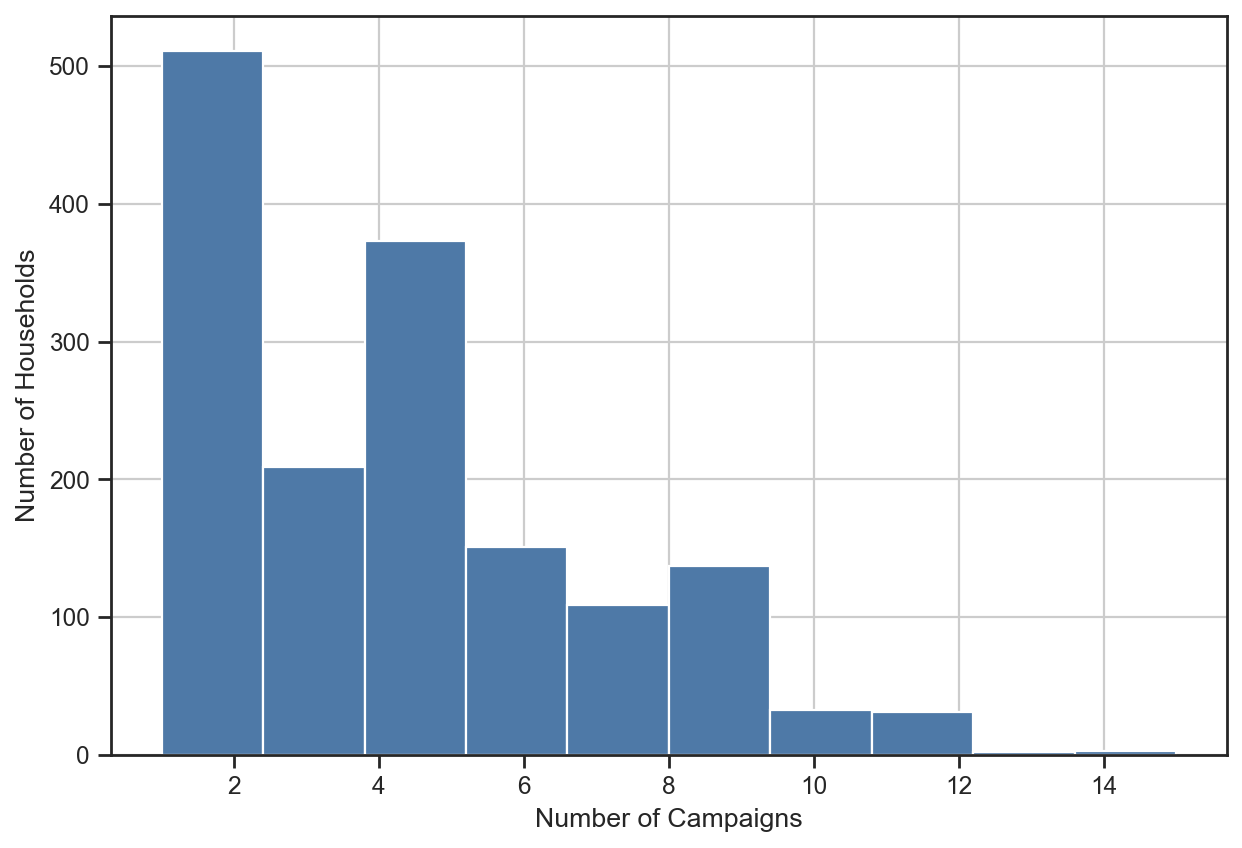

In [82]:
ax = campaigns.groupby('household_id')['campaign_id'].count().hist()
ax.set_xlabel('Number of Campaigns')
ax.set_ylabel('Number of Households')


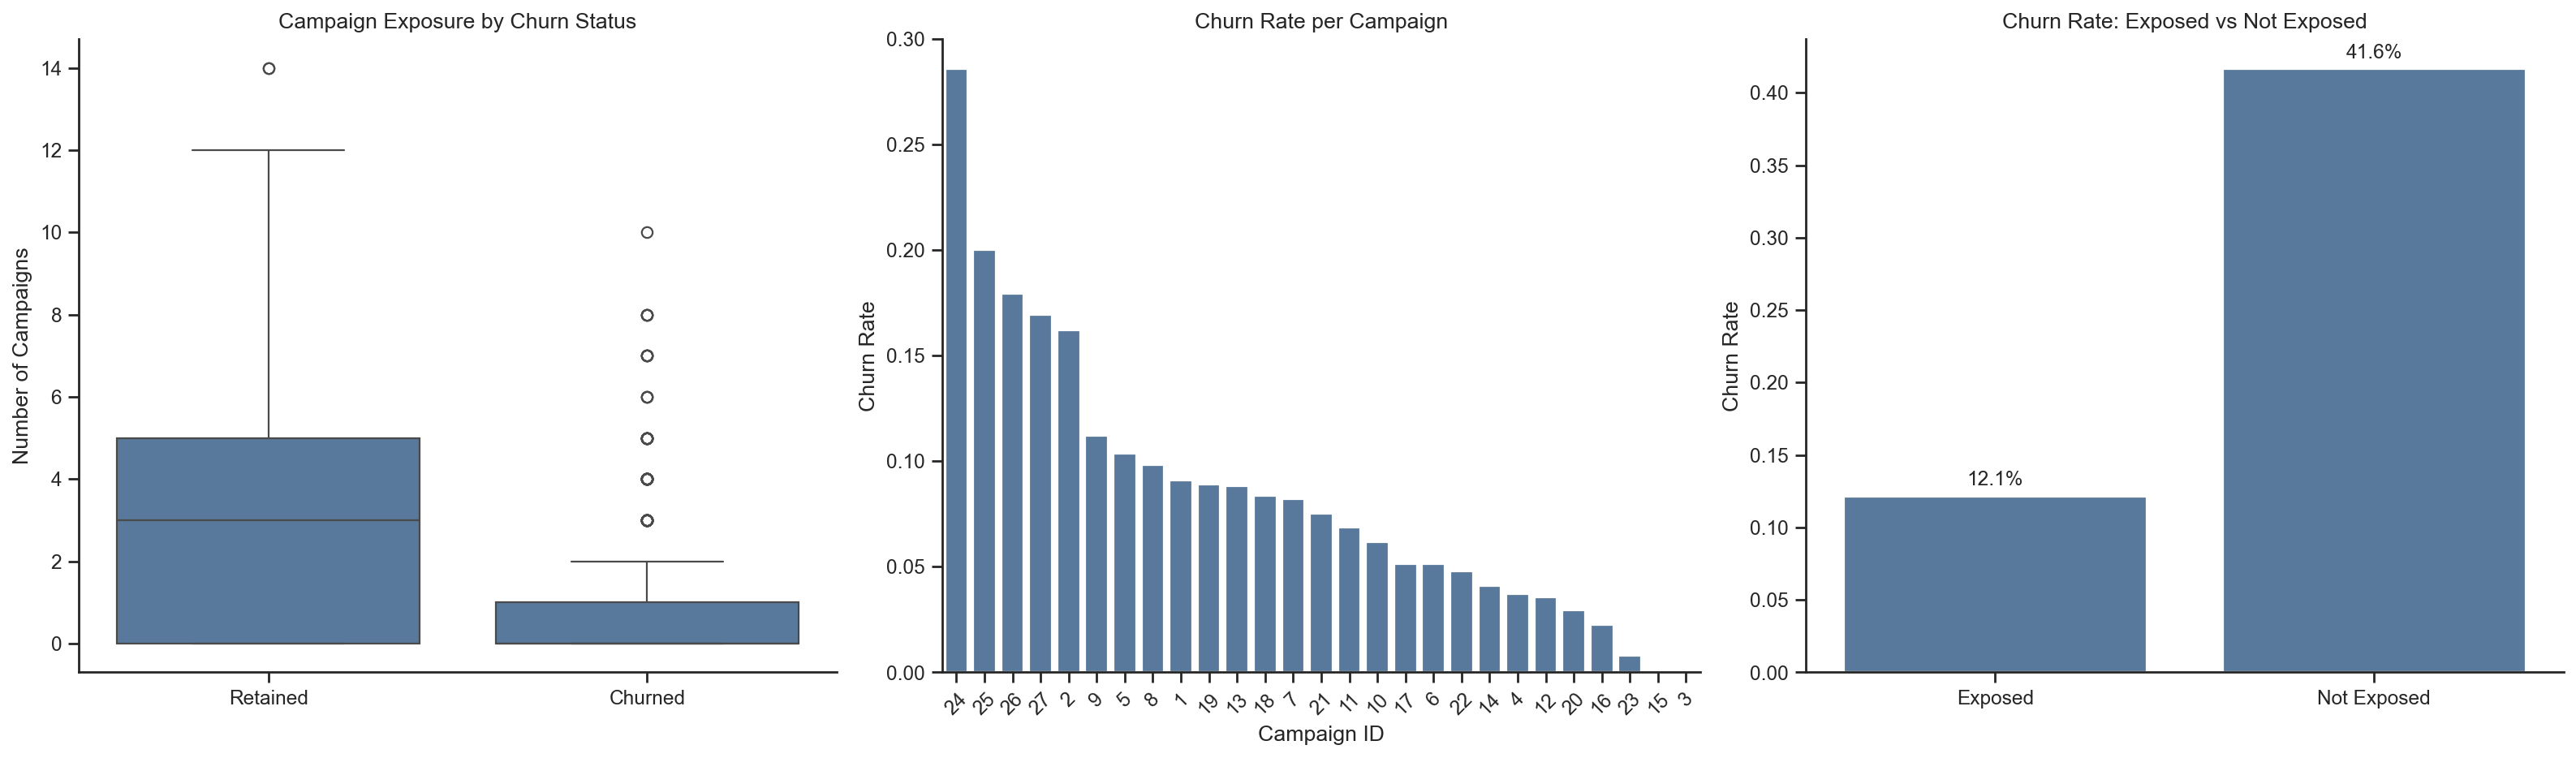

              count  mean   std  min  25%  50%  75%   max
churn_label                                              
Churned       396.0  0.95  1.77  0.0  0.0  0.0  1.0  10.0
Retained     1332.0  3.15  2.98  0.0  0.0  3.0  5.0  14.0


In [86]:
eda.plot_campaign_churn(campaigns_train, churn_train)

In [ ]:
#Feature engineering for campaigns - number of campaigns targeted and whether targeted by any campaign
n_campaigns_targeted_train = feature_eng.n_campaigns_targeted(campaigns_train, transactions_train)
n_campaigns_targeted_valid = feature_eng.n_campaigns_targeted(campaigns_valid, transactions_valid)
n_campaigns_targeted_test  = feature_eng.n_campaigns_targeted(campaigns_test, transactions_test)

was_targeted_train = feature_eng.was_targeted(campaigns_train, transactions_train)
was_targeted_valid = feature_eng.was_targeted(campaigns_valid, transactions_valid)
was_targeted_test = feature_eng.was_targeted(campaigns_test, transactions_test)

1728


# Model Building

In [25]:
X_train = log_customer_features
y_train = churn_train

X_valid = pd.DataFrame({
    'Total Spend': log_total_spend_valid,
    'Transaction Frequency': log_transaction_frequency_valid,
    'Avg Basket Size': log_average_basket_size_valid
})
y_valid = churn_valid

In [26]:
from sklearn.linear_model import LogisticRegression

logit = LogisticRegression(penalty = None)
logit.fit(X_train, y_train)

,penalty,None
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


(<Figure size 720x480 with 1 Axes>,
 <Axes: title={'center': 'Estimated coefficients'}>)

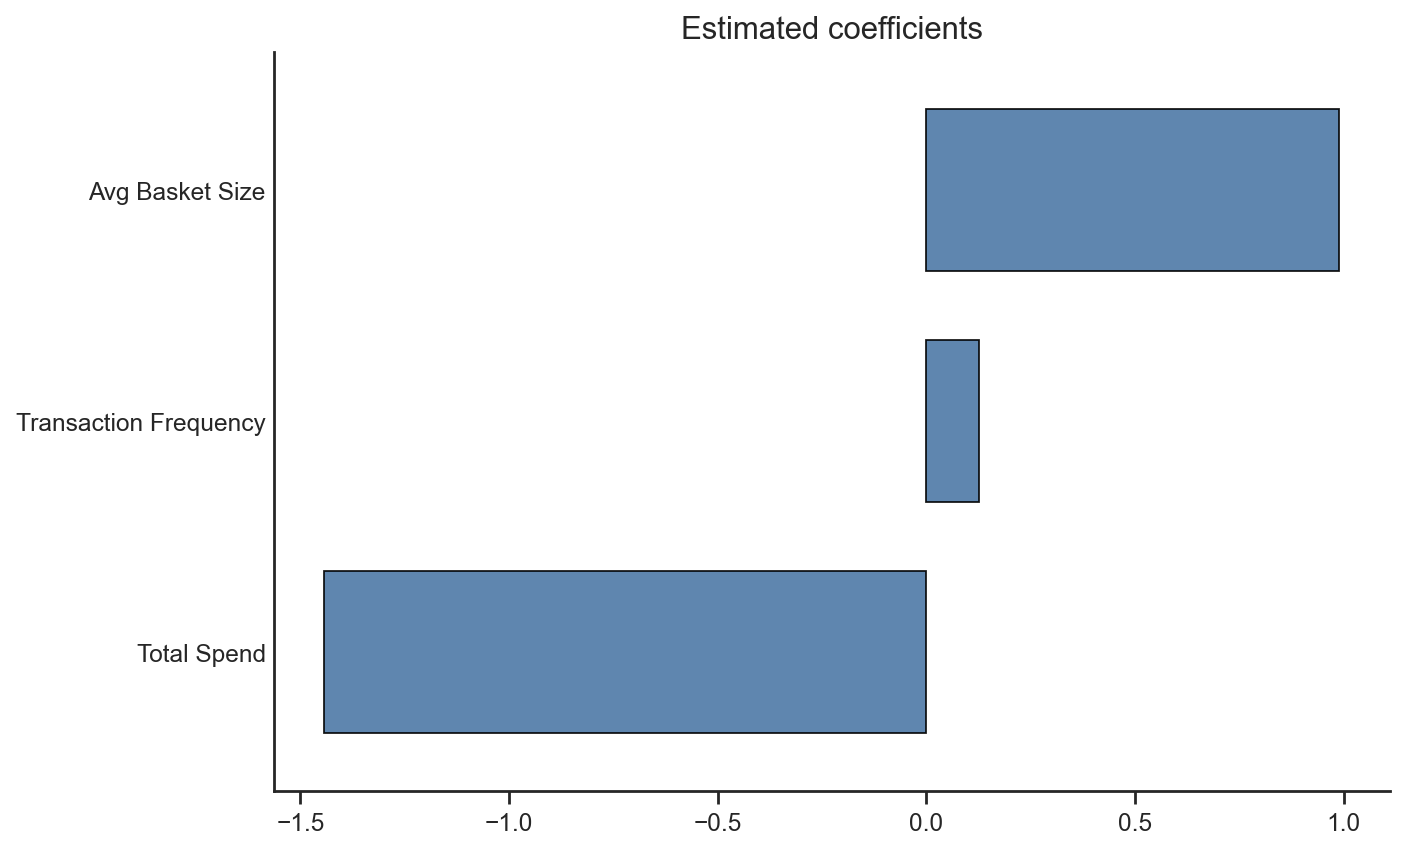

In [27]:
eda.coefplot(logit, log_customer_features.columns)

In [28]:
y_prob = logit.predict_proba(X_valid)[:, 1]  # Extract probability of default (class 1)

decision_threshold = 0.23
# Compute predicted label
y_pred = (y_prob > decision_threshold).astype(int)

# Is the customer churned?
churn_customer = (y_prob > decision_threshold).astype(int)

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

# Compute key metrics
accuracy = accuracy_score(y_valid, y_pred)
precision = precision_score(y_valid, y_pred)
recall = recall_score(y_valid, y_pred)
auc = roc_auc_score(y_valid, y_prob)

# Print results
print(f'Model Performance Metrics:')
print(f'Accuracy: {accuracy:.3f}')
print(f'Precision: {precision:.3f}')
print(f'Sensitivity: {recall:.3f}')
print(f'AUC-ROC: {auc:.3f}')

Model Performance Metrics:
Accuracy: 0.781
Precision: 0.500
Sensitivity: 0.815
AUC-ROC: 0.871
